In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


MODEL_PATH = r"C:\Users\Basant\Desktop\pbl\pimple_model.keras"
IMG_SIZE   = (224, 224)

CLASS_NAMES = [
    "bacterial_acne",
    "dietary_acne",
    "hormonal_acne",
    "hygiene_acne",
    "normal_skin",
    "stress_acne"
]

ACNE_INFO = {
    "bacterial_acne": {
        "reason": [
            "Caused by bacteria ",
            "Bacteria blocks hair follicles and causes infection",
            "Excess oil on skin feeds the bacteria",
            "Touching face with dirty hands spreads bacteria"
        ],
        "cure": [
            "Wash face twice daily with antibacterial face wash",
            "Consult doctor for antibiotic cream or tablets",
            "Do not pop or squeeze pimples"
        ]
    },
    "dietary_acne": {
        "reason": [
            "Eating too much oily and junk food",
            "High sugar intake increases insulin which triggers acne",
            "Dairy products like milk can cause hormonal changes",
            "Lack of water makes skin dry and acne prone"
        ],
        "cure": [
            "Drink at least 8 glasses of water daily",
            "Avoid oily food, chips, burger, pizza",
            "Eat more fruits and green vegetables",
            "Reduce sugar and dairy products"
        ]
    },
    "hormonal_acne": {
        "reason": [
            "Increase in androgen hormones during puberty",
            "Hormonal changes during menstrual cycle in females",
            "Excess hormones increase oil production in skin"
        ],
        "cure": [
            "Consult a dermatologist",
            "Maintain a regular sleep schedule",
            "Exercise regularly to balance hormones"
        ]
    },
    "hygiene_acne": {
        "reason": [
            "Not washing face regularly",
            "Using dirty pillow covers and towels",
            "Touching face frequently with unwashed hands",
        ],
        "cure": [
            "Wash face morning and night with mild face wash",
            "Change pillow cover every week",
            "Use clean towel and change it frequently"
        ]
    },
    "normal_skin": {
        "reason": [
            "No acne detected — your skin looks healthy!"
        ],
        "cure": [
            "Keep doing your current skincare routine",
            "Stay hydrated — drink enough water",
            "Use sunscreen daily to protect skin",
            "Eat healthy food and sleep well"
        ]
    },
    "stress_acne": {
        "reason": [
            "Stress increases cortisol hormone in body",
            "Cortisol triggers more oil production in skin",
            "Lack of sleep due to stress worsens skin condition"
        ],
        "cure": [
            "Practice meditation or deep breathing daily",
            "Get 7-8 hours of sleep every night",
            "Exercise regularly — even 30 min walk helps",
            "Avoid overthinking and take breaks from screen",
        ]
    }
}



C:\Users\Basant\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("Ready!\n")



Loading model...
Ready!



In [3]:
def predict(image_path):

    img = Image.open(image_path).convert("RGB").resize(IMG_SIZE)

    img_array = preprocess_input(np.array(img, dtype=np.float32))
    img_array = np.expand_dims(img_array, axis=0)

    pred      = model.predict(img_array, verbose=0)
    pred_idx  = np.argmax(pred)
    pred_cls  = CLASS_NAMES[pred_idx]
    label     = pred_cls.replace("_", " ").title()
    conf      = pred[0][pred_idx] * 100
    info      = ACNE_INFO[pred_cls]

    print(f"\n{'=' * 55}")
    print(f"  Image      : {os.path.basename(image_path)}")
    print(f"  Detected   : {label}")
    print(f"  Confidence : {conf:.1f}%")
    print(f"{'─' * 55}")

    print("\n  All Probabilities:")
    for i, cls in enumerate(CLASS_NAMES):
        bar = "\u2588" * int(pred[0][i] * 40)
        print(f"    {cls:<22}  {pred[0][i]*100:5.1f}%  {bar}")

    print(f"\n  REASONS:")
    for i, r in enumerate(info["reason"], 1):
        print(f"    {i}. {r}")

    print(f"\n  CURE:")
    for i, c in enumerate(info["cure"], 1):
        print(f"    {i}. {c}")
    print(f"{'=' * 55}\n")


    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(np.array(Image.open(image_path).convert("RGB")))
    axes[0].set_title(f"Detected: {label}\nConfidence: {conf:.1f}%",
                      fontsize=12, fontweight="bold",
                      color="green" if pred_cls == "normal_skin" else "red")
    axes[0].axis("off")
    axes[1].axis("off")
    text = "REASONS:\n"
    for i, r in enumerate(info["reason"], 1):
        text += f"  {i}. {r}\n"
    text += "\nCURE:\n"
    for i, c in enumerate(info["cure"], 1):
        text += f"  {i}. {c}\n"
    axes[1].text(0, 1, text, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment="top",
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    plt.suptitle(f"Pimple Detection: {label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("prediction_result.png", dpi=150)
    plt.show()




  Image      : test_image_6.jpg
  Detected   : Hygiene Acne
  Confidence : 90.7%
───────────────────────────────────────────────────────

  All Probabilities:
    bacterial_acne            4.6%  █
    dietary_acne              2.0%  
    hormonal_acne             1.4%  
    hygiene_acne             90.7%  ████████████████████████████████████
    normal_skin               1.2%  
    stress_acne               0.1%  

  REASONS:
    1. Not washing face regularly
    2. Using dirty pillow covers and towels
    3. Touching face frequently with unwashed hands

  CURE:
    1. Wash face morning and night with mild face wash
    2. Change pillow cover every week
    3. Use clean towel and change it frequently



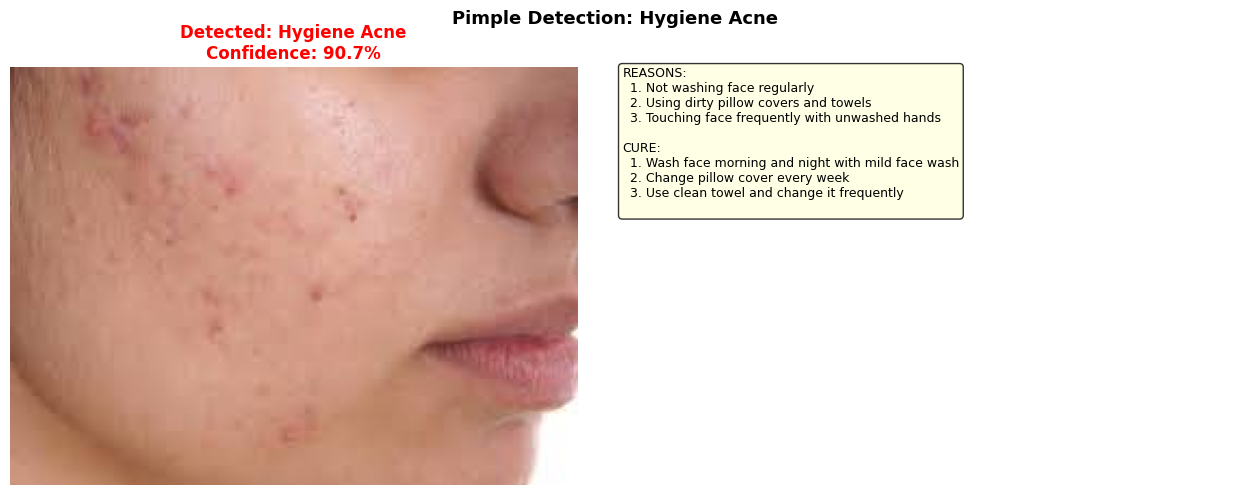

In [13]:
predict(r"C:\Users\Basant\Desktop\pbl\test_image_6.jpg")


  Image      : test_image_2.jpg
  Detected   : Bacterial Acne
  Confidence : 65.9%
───────────────────────────────────────────────────────

  All Probabilities:
    bacterial_acne           65.9%  ██████████████████████████
    dietary_acne              5.9%  ██
    hormonal_acne             9.1%  ███
    hygiene_acne             17.3%  ██████
    normal_skin               0.4%  
    stress_acne               1.4%  

  REASONS:
    1. Caused by bacteria 
    2. Bacteria blocks hair follicles and causes infection
    3. Excess oil on skin feeds the bacteria
    4. Touching face with dirty hands spreads bacteria

  CURE:
    1. Wash face twice daily with antibacterial face wash
    2. Consult doctor for antibiotic cream or tablets
    3. Do not pop or squeeze pimples



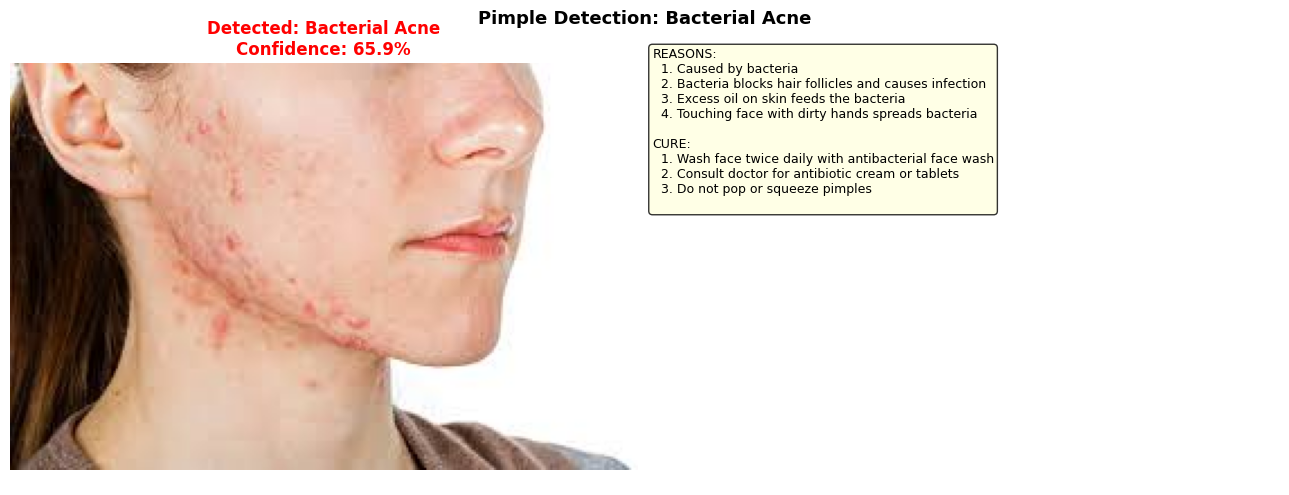

In [19]:
predict(r"C:\Users\Basant\Desktop\pbl\test_image_2.jpg")